# Comparative & Explainable Deep Learning with CBAM for DEEPFAKE Vs REAL Image Detection. 

## CELL 0 — ENVIRONMENT SETUP

In [1]:
import os, gc, time, random, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications, callbacks, mixed_precision
 
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
 
# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
 
# ── Mixed precision: cuts GPU memory ~40% with no accuracy loss ───
mixed_precision.set_global_policy("mixed_float16")
print(f"Mixed precision : {mixed_precision.global_policy().name}")
 
# ── Memory growth: prevents TF grabbing all GPU RAM at startup ────
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Memory growth   : enabled on {gpu.name}")
    except RuntimeError as e:
        print(f"Memory growth   : {e}")
 
print(f"TensorFlow      : {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available  : {len(gpus)}")
if not gpus:
    print("WARNING: No GPU detected. Enable in Kaggle Settings -> Accelerator -> GPU T4 x2")

2026-04-09 23:42:19.745399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775778139.961972      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775778140.023776      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775778140.519417      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775778140.519453      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775778140.519455      55 computation_placer.cc:177] computation placer alr

Mixed precision : mixed_float16
Memory growth   : enabled on /physical_device:GPU:0
Memory growth   : enabled on /physical_device:GPU:1
TensorFlow      : 2.19.0
GPUs available  : 2


#  PHASE 1 — DATASET SETUP, CUSTOM SPLIT & EDA

## Cell 1.1 — Paths

In [2]:
DATASET_ROOT = Path("/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset")
SPLIT_CSV    = Path("custom_split.csv")   # saved to disk, reused across sessions
RESULTS_DIR  = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)

## Cell 1.2 — Build master DataFrame from ALL images

In [3]:
print("Scanning all images...")
records = []
for orig_split in ["Train", "Validation", "Test"]:
    for cls in ["Real", "Fake"]:
        folder = DATASET_ROOT / orig_split / cls
        for img_path in folder.glob("*.*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                records.append({
                    "path"      : str(img_path),
                    "label"     : cls,
                    "label_int" : 0 if cls == "Real" else 1,
                })
 
df_all = pd.DataFrame(records)
print(f"Total images found : {len(df_all):,}")
print(df_all["label"].value_counts())

Scanning all images...
Total images found : 190,335
label
Real    95201
Fake    95134
Name: count, dtype: int64


## Cell 1.3 — Stratified 70 / 15 / 15 split

In [4]:
if SPLIT_CSV.exists():
    print(f"\nLoading existing split from {SPLIT_CSV}")
    df_all = pd.read_csv(SPLIT_CSV)
else:
    print("\nCreating stratified 70/15/15 split...")
 
    # Step 1: 70% train, 30% temp
    train_df, temp_df = train_test_split(
        df_all, test_size=0.30,
        stratify=df_all["label_int"],
        random_state=SEED)
 
    # Step 2: split temp 50/50 → 15% val, 15% test
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50,
        stratify=temp_df["label_int"],
        random_state=SEED)
 
    train_df = train_df.copy(); train_df["split"] = "train"
    val_df   = val_df.copy();   val_df["split"]   = "val"
    test_df  = test_df.copy();  test_df["split"]  = "test"
 
    df_all = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
    df_all.to_csv(SPLIT_CSV, index=False)
    print(f"Split saved to {SPLIT_CSV}")
 
# Summary
for split in ["train", "val", "test"]:
    sdf   = df_all[df_all["split"] == split]
    real  = len(sdf[sdf["label"] == "Real"])
    fake  = len(sdf[sdf["label"] == "Fake"])
    total = len(sdf)
    print(f"  {split:6s} : {total:7,} total  "
          f"Real={real:,} ({real/total*100:.1f}%)  "
          f"Fake={fake:,} ({fake/total*100:.1f}%)")


Creating stratified 70/15/15 split...
Split saved to custom_split.csv
  train  : 133,234 total  Real=66,640 (50.0%)  Fake=66,594 (50.0%)
  val    :  28,550 total  Real=14,280 (50.0%)  Fake=14,270 (50.0%)
  test   :  28,551 total  Real=14,281 (50.0%)  Fake=14,270 (50.0%)


## Cell 1.4 — Class distribution plot

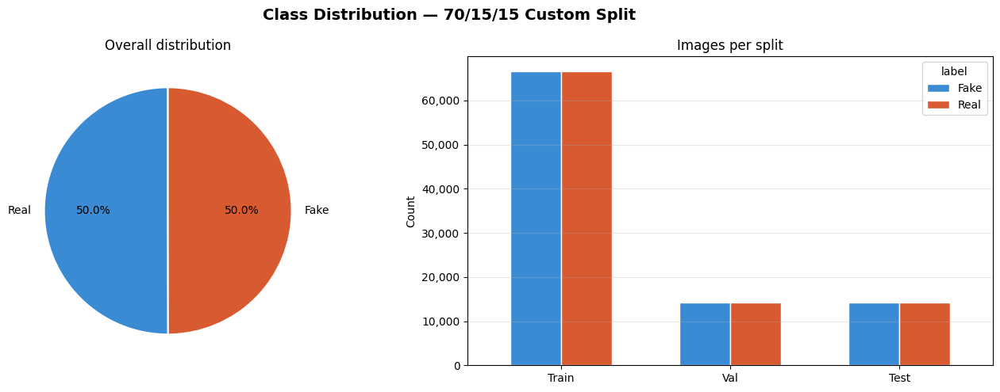

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution — 70/15/15 Custom Split",
             fontsize=14, fontweight="bold")
 
overall = df_all["label"].value_counts()
axes[0].pie(overall, labels=overall.index, autopct="%1.1f%%",
            colors=["#3B8BD4","#D85A30"], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Overall distribution")
 
split_counts = (df_all.groupby(["split","label"])
                      .size().unstack()
                      .reindex(["train","val","test"]))
split_counts.plot(kind="bar", ax=axes[1],
                  color=["#3B8BD4","#D85A30"],
                  edgecolor="white", width=0.6)
axes[1].set_title("Images per split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Train","Val","Test"], rotation=0)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("p1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 1.5 — Sample image grid

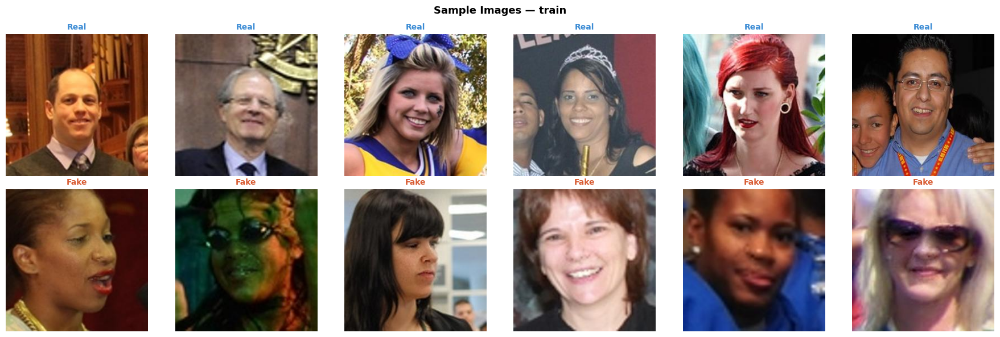

In [6]:
def show_sample_grid(df, split="train", n=6):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    fig.suptitle(f"Sample Images — {split}", fontsize=13, fontweight="bold")
    for ri, cls in enumerate(["Real","Fake"]):
        subset = (df[(df["split"]==split) & (df["label"]==cls)]
                    .sample(n, random_state=SEED))
        for ci, (_, row) in enumerate(subset.iterrows()):
            axes[ri][ci].imshow(Image.open(row["path"]).convert("RGB"))
            axes[ri][ci].set_title(
                cls, fontsize=10, fontweight="bold",
                color="#3B8BD4" if cls=="Real" else "#D85A30")
            axes[ri][ci].axis("off")
    plt.tight_layout()
    plt.savefig(f"p1_sample_grid_{split}.png", dpi=150, bbox_inches="tight")
    plt.show()
 
show_sample_grid(df_all, "train", 6)

## Cell 1.6 — Image property analysis

Analysing image properties (500 samples)...
Width  : mean=256  std=0
Height : mean=256  std=0
Size   : mean=9.3 KB


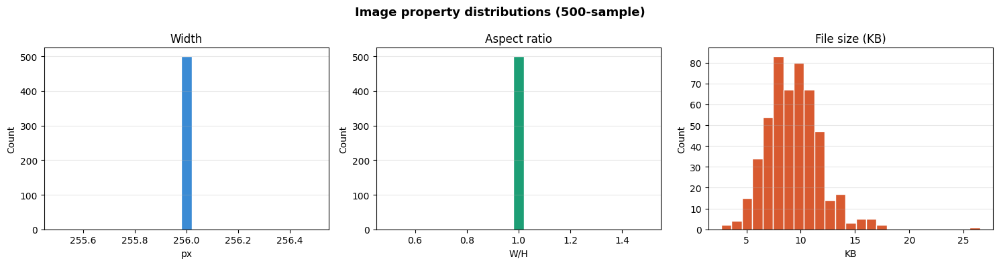

In [7]:
print("Analysing image properties (500 samples)...")
sample_rows = df_all.sample(min(500, len(df_all)), random_state=SEED)
widths, heights, aspects, sizes_kb = [], [], [], []
for _, row in sample_rows.iterrows():
    try:
        with Image.open(row["path"]) as img:
            w, h = img.size
        widths.append(w); heights.append(h)
        aspects.append(round(w/h, 2))
        sizes_kb.append(os.path.getsize(row["path"])/1024)
    except Exception:
        pass
 
print(f"Width  : mean={np.mean(widths):.0f}  std={np.std(widths):.0f}")
print(f"Height : mean={np.mean(heights):.0f}  std={np.std(heights):.0f}")
print(f"Size   : mean={np.mean(sizes_kb):.1f} KB")
 
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle("Image property distributions (500-sample)",
             fontsize=13, fontweight="bold")
for ax, data, title, xlabel, col in zip(
    axes,
    [widths, aspects, sizes_kb],
    ["Width","Aspect ratio","File size (KB)"],
    ["px","W/H","KB"],
    ["#3B8BD4","#1D9E75","#D85A30"]
):
    ax.hist(data, bins=25, color=col, edgecolor="white")
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.set_ylabel("Count"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("p1_image_properties.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 1.7 — Pixel intensity analysis

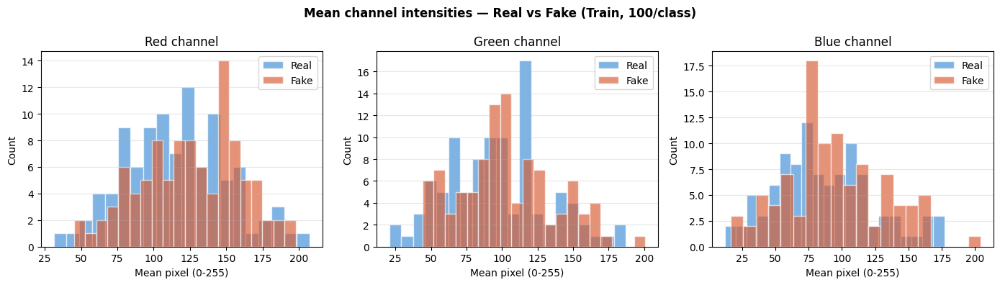

Phase 1 complete.


In [8]:
def mean_pixel(path, size=(128,128)):
    try:
        return np.array(
            Image.open(path).convert("RGB").resize(size)
        ).mean(axis=(0,1))
    except Exception:
        return None
 
intensity = {"Real":[], "Fake":[]}
for cls in ["Real","Fake"]:
    subset = (df_all[(df_all["split"]=="train") & (df_all["label"]==cls)]
                .sample(100, random_state=SEED))
    for _, row in subset.iterrows():
        m = mean_pixel(row["path"])
        if m is not None: intensity[cls].append(m)
 
fig, axes = plt.subplots(1, 3, figsize=(14,4))
fig.suptitle("Mean channel intensities — Real vs Fake (Train, 100/class)",
             fontsize=12, fontweight="bold")
for ci, ch in enumerate(["Red","Green","Blue"]):
    axes[ci].hist([v[ci] for v in intensity["Real"]], bins=20, alpha=0.65,
                  color="#3B8BD4", label="Real", edgecolor="white")
    axes[ci].hist([v[ci] for v in intensity["Fake"]], bins=20, alpha=0.65,
                  color="#D85A30", label="Fake", edgecolor="white")
    axes[ci].set_title(f"{ch} channel")
    axes[ci].set_xlabel("Mean pixel (0-255)")
    axes[ci].set_ylabel("Count")
    axes[ci].legend(); axes[ci].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("p1_pixel_intensity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Phase 1 complete.")

#  PHASE 2 — DATA PIPELINE

## Cell 2.1 — Hyperparameters

In [9]:
IMG_SIZE     = 224   
BATCH_SIZE   = 32    
NUM_WARMUP   = 3     
NUM_FINETUNE = 10     
LR_WARMUP    = 1e-3
LR_FINETUNE  = 1e-4
PATIENCE     = 3     
AUTOTUNE     = tf.data.AUTOTUNE
 
STEPS_PER_EPOCH       = 1000
VALIDATION_STEPS      = 400   
 
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
 
print(f"IMG_SIZE={IMG_SIZE}  BATCH={BATCH_SIZE}")
print(f"Steps/epoch={STEPS_PER_EPOCH}  Val steps={VALIDATION_STEPS}")
print(f"Warmup={NUM_WARMUP} ep  Finetune={NUM_FINETUNE} ep  Patience={PATIENCE}")

IMG_SIZE=224  BATCH=32
Steps/epoch=1000  Val steps=400
Warmup=3 ep  Finetune=10 ep  Patience=3


I0000 00:00:1775778184.461193      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775778184.467381      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Cell 2.2 — Load split CSV

In [10]:
if not SPLIT_CSV.exists():
    raise FileNotFoundError(
        f"{SPLIT_CSV} not found. Run Phase 1 (Cell 1.3) first "
        f"to create the split.")
 
df_all = pd.read_csv(SPLIT_CSV)
train_df = df_all[df_all["split"] == "train"].reset_index(drop=True)
val_df   = df_all[df_all["split"] == "val"].reset_index(drop=True)
test_df  = df_all[df_all["split"] == "test"].reset_index(drop=True)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

Train: 133,234  Val: 28,550  Test: 28,551


## Cell 2.3 — Class weights

In [11]:
real_n = len(train_df[train_df["label"] == "Real"])
fake_n = len(train_df[train_df["label"] == "Fake"])
total  = len(train_df)
class_weight = {
    0: total / (2 * real_n),   # 0 = Real
    1: total / (2 * fake_n),   # 1 = Fake
}
print(f"Real={real_n:,}  Fake={fake_n:,}")
print(f"Class weights: Real={class_weight[0]:.4f}  Fake={class_weight[1]:.4f}")

Real=66,640  Fake=66,594
Class weights: Real=0.9997  Fake=1.0003


## Cell 2.4 — tf.data pipeline from file path lists

In [12]:
aug_layer = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name="augmentation")
 
def load_and_preprocess(path, label):
    """Load image from path, decode, resize, normalise."""
    img  = tf.io.read_file(path)
    img  = tf.image.decode_image(img, channels=3, expand_animations=False)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.cast(img, tf.float32) / 255.0
    img  = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, label
 
def load_aug_preprocess(path, label):
    """Same as above but with augmentation — for training only."""
    img  = tf.io.read_file(path)
    img  = tf.image.decode_image(img, channels=3, expand_animations=False)
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = aug_layer(tf.expand_dims(img, 0), training=True)[0]
    img  = tf.cast(img, tf.float32) / 255.0
    img  = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, label
 
def build_dataset(df, augment=False, shuffle=False):
    paths  = df["path"].values
    labels = df["label_int"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10000, seed=SEED, reshuffle_each_iteration=True)
    fn = load_aug_preprocess if augment else load_and_preprocess
    ds = ds.map(fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds
 
train_ds = build_dataset(train_df, augment=True,  shuffle=True)
val_ds   = build_dataset(val_df,   augment=False, shuffle=False)
test_ds  = build_dataset(test_df,  augment=False, shuffle=False)
 
print("Pipelines ready.")
print(f"Train batches : {len(train_ds):,}  "
      f"(using {STEPS_PER_EPOCH} steps/epoch)")
print(f"Val batches   : {len(val_ds):,}  "
      f"(using {VALIDATION_STEPS} val_steps)")
print(f"Test batches  : {len(test_ds):,}  (full — used only for final eval)")

Pipelines ready.
Train batches : 4,164  (using 1000 steps/epoch)
Val batches   : 893  (using 400 val_steps)
Test batches  : 893  (full — used only for final eval)


## Cell 2.5 — Batch sanity check

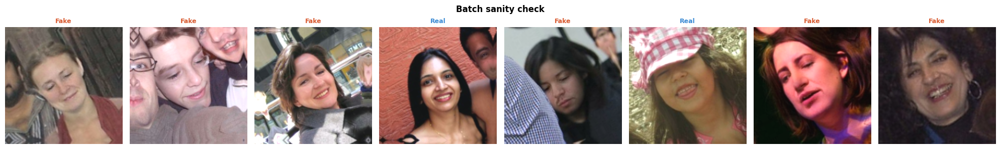

images=(32, 224, 224, 3)  labels=(32,)
Phase 2 complete.


In [13]:
imgs, lbls = next(iter(train_ds))
disp = np.clip(
    imgs[:8].numpy() * IMAGENET_STD.numpy() + IMAGENET_MEAN.numpy(), 0, 1)
lmap = {0:"Real",1:"Fake"}; cmap_l = {0:"#3B8BD4",1:"#D85A30"}
fig, axes = plt.subplots(1, 8, figsize=(20,3))
fig.suptitle("Batch sanity check", fontsize=12, fontweight="bold")
for i, ax in enumerate(axes):
    ax.imshow(disp[i]); ax.axis("off")
    lbl = int(lbls[i].numpy())
    ax.set_title(lmap[lbl], color=cmap_l[lbl],
                 fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("p2_batch_sanity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"images={imgs.shape}  labels={lbls.shape}")
print("Phase 2 complete.")

#  SHARED UTILITIES

In [14]:
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=16, **kw):
        super().__init__(**kw)
        self.reduction_ratio = reduction_ratio
    def build(self, input_shape):
        c   = input_shape[-1]
        mid = max(1, c // self.reduction_ratio)
        self.avg_pool = layers.GlobalAveragePooling2D(keepdims=True)
        self.max_pool = layers.GlobalMaxPooling2D(keepdims=True)
        self.d1 = layers.Dense(mid, activation="relu",  use_bias=False)
        self.d2 = layers.Dense(c,   activation=None,    use_bias=False)
        super().build(input_shape)
    def call(self, x):
        return tf.sigmoid(self.d2(self.d1(self.avg_pool(x))) +
                          self.d2(self.d1(self.max_pool(x))))
 
class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kw):
        super().__init__(**kw)
        self.conv = layers.Conv2D(1, kernel_size, padding="same",
                                  activation="sigmoid", use_bias=False)
    def call(self, x):
        avg_c = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_c = tf.reduce_max(x,  axis=-1, keepdims=True)
        return self.conv(tf.concat([avg_c, max_c], axis=-1))
 
class CBAM(layers.Layer):
    """CBAM — Woo et al. ECCV 2018. Channel then spatial attention."""
    def __init__(self, reduction_ratio=16, spatial_kernel=7, **kw):
        super().__init__(**kw)
        self.channel_att = ChannelAttention(reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)
    def call(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x
 
# Smoke test
assert CBAM()(tf.random.normal((2,14,14,64))).shape == (2,14,14,64)
print("CBAM OK")
 
CUSTOM_OBJECTS = {
    "CBAM"            : CBAM,
    "ChannelAttention" : ChannelAttention,
    "SpatialAttention" : SpatialAttention,
}
 
# ── Metrics and callbacks ─────────────────────────────────────────
def make_metrics():
    return [
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ]
 
def ckpt_path(model_name, suffix):
    return f"{model_name.lower()}_{suffix}.keras"
 
def checkpoint_exists(model_name, suffix):
    return Path(ckpt_path(model_name, suffix)).exists()
 
def make_callbacks(model_name, suffix):
    return [
        callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(
            ckpt_path(model_name, suffix),
            monitor="val_auc", mode="max",
            save_best_only=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max",
            factor=0.5, patience=2,
            min_lr=1e-7, verbose=1),
    ]
 
# ── Training function ─────────────────────────────────────────────
def train_two_stage(model, backbone, model_name, suffix, n_unfreeze=20):
    """
    Stage 1 — freeze backbone, train head only (NUM_WARMUP epochs).
    Stage 2 — unfreeze last n_unfreeze backbone layers (NUM_FINETUNE epochs).
    steps_per_epoch and validation_steps cap each epoch to avoid
    the ~20 min per epoch problem on 140k images.
    """
    cbs = make_callbacks(model_name, suffix)
    t0  = time.time()
 
    print(f"  Stage 1 — warmup ({NUM_WARMUP} ep, "
          f"{STEPS_PER_EPOCH} steps each) ...")
    h1 = model.fit(
        train_ds,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=val_ds,
        validation_steps=VALIDATION_STEPS,
        epochs=NUM_WARMUP,
        class_weight=class_weight,
        callbacks=cbs,
        verbose=1
    )
 
    print(f"  Stage 2 — fine-tune (last {n_unfreeze} layers, "
          f"{NUM_FINETUNE} ep max) ...")
    backbone.trainable = True
    for layer in backbone.layers[:-n_unfreeze]:
        layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(LR_FINETUNE),
        loss="binary_crossentropy",
        metrics=make_metrics()
    )
    h2 = model.fit(
        train_ds,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=val_ds,
        validation_steps=VALIDATION_STEPS,
        epochs=NUM_FINETUNE,
        class_weight=class_weight,
        callbacks=cbs,
        verbose=1
    )
 
    elapsed = time.time() - t0
    print(f"  Done in {elapsed/60:.1f} min")
 
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history[k]
    return model, history
 
# ── Evaluate on FULL test set ─────────────────────────────────────
def evaluate_model(model):
    """Runs inference on the full test set (no steps cap)."""
    y_true, y_prob = [], []
    for imgs, lbls in test_ds:
        probs = model(imgs, training=False).numpy().flatten()
        y_prob.extend(probs.tolist())
        y_true.extend(lbls.numpy().flatten().tolist())
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy" : round(float(accuracy_score(y_true, y_pred)), 4),
        "F1"       : round(float(f1_score(y_true, y_pred)), 4),
        "AUC"      : round(float(roc_auc_score(y_true, y_prob)), 4),
        "Precision": round(float(tp/(tp+fp+1e-9)), 4),
        "Recall"   : round(float(tp/(tp+fn+1e-9)), 4),
        "TP":int(tp), "TN":int(tn), "FP":int(fp), "FN":int(fn),
        "y_true"   : y_true.tolist(),
        "y_prob"   : y_prob.tolist(),
    }
 
# ── Persist results to disk ───────────────────────────────────────
def save_result(model_name, suffix, metrics_dict, history_dict):
    out = {
        "model_name": model_name,
        "suffix"    : suffix,
        "metrics"   : {k:v for k,v in metrics_dict.items()
                       if k not in ["y_true","y_prob"]},
        "y_true"    : metrics_dict["y_true"],
        "y_prob"    : metrics_dict["y_prob"],
        "history"   : history_dict,
    }
    path = RESULTS_DIR / f"{model_name}_{suffix}.json"
    with open(path,"w") as f: json.dump(out, f)
    print(f"  Saved -> {path}")
 
def load_result(model_name, suffix):
    path = RESULTS_DIR / f"{model_name}_{suffix}.json"
    if path.exists():
        with open(path) as f: return json.load(f)
    return None
 
def load_model_safe(model_name, suffix):
    p = ckpt_path(model_name, suffix)
    if not Path(p).exists():
        print(f"  Checkpoint missing: {p}"); return None
    return keras.models.load_model(p, custom_objects=CUSTOM_OBJECTS)
 
metrics_cols = ["Accuracy","F1","AUC","Precision","Recall"]
 
def build_summary(all_results, suffix):
    rows = []
    for mn, sd in all_results.items():
        if suffix in sd:
            m = sd[suffix]["metrics"]
            rows.append({"Model":mn, **{k:m[k] for k in metrics_cols}})
    return pd.DataFrame(rows).set_index("Model") if rows else pd.DataFrame()
 
def load_all_results():
    model_names = ["ResNet50","EfficientNetB4","Xception"]
    out = {}
    for mn in model_names:
        out[mn] = {}
        for sf in ["baseline","cbam"]:
            r = load_result(mn, sf)
            if r is None:
                print(f"  Not yet available: {mn} {sf}")
            else:
                out[mn][sf] = r
    return out
 
print("Shared utilities loaded.")

I0000 00:00:1775778190.577560      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


CBAM OK
Shared utilities loaded.


#  PHASE 3 & 4 — MODEL TRAINING

## Cell 3A — ResNet50 Baseline

In [15]:
keras.backend.clear_session(); gc.collect()
 
_MN = "ResNet50"; _SF = "baseline"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    resnet50_base    = load_model_safe(_MN, _SF)
    r50_base_result  = load_result(_MN, _SF)
    r50_base_hist    = r50_base_result["history"] if r50_base_result else {}
    print(f"  AUC = {r50_base_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.ResNet50(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = layers.GlobalAveragePooling2D()(_bb.output)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    resnet50_base = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    resnet50_base.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    resnet50_base, r50_base_hist = train_two_stage(
        resnet50_base, _bb, _MN, _SF, n_unfreeze=20)
    r50_base_result = evaluate_model(resnet50_base)
    save_result(_MN, _SF, r50_base_result, r50_base_hist)
    print(f"  AUC = {r50_base_result['AUC']}")

[TRAIN] ResNet50 baseline
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3


I0000 00:00:1775778200.771766     127 service.cc:152] XLA service 0x7b8710014210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775778200.771803     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775778200.771807     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/1000 ━━━━━━━━━━━━━━━━━━━━ 4:19:53 16s/step - accuracy: 0.5312 - auc: 0.6833 - loss: 0.6820 - precision: 0.4286 - recall: 0.7500

I0000 00:00:1775778209.040757     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6461 - auc: 0.6950 - loss: 0.7296 - precision: 0.6457 - recall: 0.6500
Epoch 1: val_auc improved from -inf to 0.77342, saving model to resnet50_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 437s 422ms/step - accuracy: 0.6461 - auc: 0.6950 - loss: 0.7296 - precision: 0.6458 - recall: 0.6500 - val_accuracy: 0.6913 - val_auc: 0.7734 - val_loss: 0.5738 - val_precision: 0.6681 - val_recall: 0.7603 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6937 - auc: 0.7576 - loss: 0.5851 - precision: 0.6983 - recall: 0.6799
Epoch 2: val_auc improved from 0.77342 to 0.79910, saving model to resnet50_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 385s 386ms/step - accuracy: 0.6937 - auc: 0.7576 - loss: 0.5851 - precision: 0.6983 - recall: 0.6799 - val_accuracy: 0.7151 - val_auc: 0.7991 - val_loss: 0.5482 - val_precision: 0.6906 - val_recall: 0.7796 - learning_rate: 0.0010
Epoch 3/3
1000/1000 ━━━━━━━━━

## Cell 3B — ResNet50 + CBAM

In [16]:
keras.backend.clear_session(); gc.collect()
 
_MN = "ResNet50"; _SF = "cbam"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    resnet50_cbam   = load_model_safe(_MN, _SF)
    r50_cbam_result = load_result(_MN, _SF)
    r50_cbam_hist   = r50_cbam_result["history"] if r50_cbam_result else {}
    print(f"  AUC = {r50_cbam_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.ResNet50(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = CBAM(name="cbam")(_bb.output)
    _x = layers.GlobalAveragePooling2D()(_x)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    resnet50_cbam = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    resnet50_cbam.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    resnet50_cbam, r50_cbam_hist = train_two_stage(
        resnet50_cbam, _bb, _MN, _SF, n_unfreeze=20)
    r50_cbam_result = evaluate_model(resnet50_cbam)
    save_result(_MN, _SF, r50_cbam_result, r50_cbam_hist)
    print(f"  AUC = {r50_cbam_result['AUC']}")

[TRAIN] ResNet50 cbam
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6318 - auc: 0.6786 - loss: 0.6841 - precision: 0.6293 - recall: 0.6289
Epoch 1: val_auc improved from -inf to 0.77870, saving model to resnet50_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 359s 344ms/step - accuracy: 0.6318 - auc: 0.6786 - loss: 0.6840 - precision: 0.6293 - recall: 0.6289 - val_accuracy: 0.7049 - val_auc: 0.7787 - val_loss: 0.5681 - val_precision: 0.7278 - val_recall: 0.6549 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6759 - auc: 0.7400 - loss: 0.6001 - precision: 0.6803 - recall: 0.6623
Epoch 2: val_auc improved from 0.77870 to 0.79402, saving model to resnet50_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 379s 379ms/step - accuracy: 0.6759 - auc: 0.7401 - loss: 0.6001 - precision: 0.6803 - recall: 0.6623 - val_accuracy: 0.7138 - val_auc: 0.7940 - val_loss: 0.5525 - val_precision: 0.6957 - v

## Cell 3C — EfficientNetB4 Baseline

In [17]:
keras.backend.clear_session(); gc.collect()
 
_MN = "EfficientNetB4"; _SF = "baseline"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    effnet_base     = load_model_safe(_MN, _SF)
    eff_base_result = load_result(_MN, _SF)
    eff_base_hist   = eff_base_result["history"] if eff_base_result else {}
    print(f"  AUC = {eff_base_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.EfficientNetB4(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = layers.GlobalAveragePooling2D()(_bb.output)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    effnet_base = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    effnet_base.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    effnet_base, eff_base_hist = train_two_stage(
        effnet_base, _bb, _MN, _SF, n_unfreeze=20)
    eff_base_result = evaluate_model(effnet_base)
    save_result(_MN, _SF, eff_base_result, eff_base_hist)
    print(f"  AUC = {eff_base_result['AUC']}")

[TRAIN] EfficientNetB4 baseline
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3


2026-04-10 02:10:10.825567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:10:10.963116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:10:11.220543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:10:11.364102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:10:11.664628: E external/local_xla/xla/stream_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5956 - auc: 0.6329 - loss: 0.8382 - precision: 0.5941 - recall: 0.5927
Epoch 1: val_auc improved from -inf to 0.73261, saving model to efficientnetb4_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 399s 347ms/step - accuracy: 0.5956 - auc: 0.6329 - loss: 0.8381 - precision: 0.5941 - recall: 0.5927 - val_accuracy: 0.6578 - val_auc: 0.7326 - val_loss: 0.6031 - val_precision: 0.6493 - val_recall: 0.6865 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6337 - auc: 0.6899 - loss: 0.6337 - precision: 0.6354 - recall: 0.6167
Epoch 2: val_auc did not improve from 0.73261
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 373s 374ms/step - accuracy: 0.6337 - auc: 0.6899 - loss: 0.6337 - precision: 0.6354 - recall: 0.6167 - val_accuracy: 0.6541 - val_auc: 0.7221 - val_loss: 0.6127 - val_precision: 0.6689 - val_recall: 0.6104 - learning_rate: 0.0010
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0

2026-04-10 02:54:00.646690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:54:00.780155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:54:01.018081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:54:01.158892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 02:54:01.420936: E external/local_xla/xla/stream_

 164/1000 ━━━━━━━━━━━━━━━━━━━━ 5:54 424ms/step - accuracy: 0.7142 - auc: 0.7920 - loss: 0.5459 - precision: 0.7231 - recall: 0.6716
Epoch 5: val_auc did not improve from 0.82708
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 104s 104ms/step - accuracy: 0.7163 - auc: 0.7948 - loss: 0.5429 - precision: 0.7320 - recall: 0.6783 - val_accuracy: 0.7244 - val_auc: 0.8177 - val_loss: 0.5183 - val_precision: 0.7661 - val_recall: 0.6461 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.7158 - auc: 0.7949 - loss: 0.5420 - precision: 0.7246 - recall: 0.6946
Epoch 6: val_auc did not improve from 0.82708

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 381s 340ms/step - accuracy: 0.7157 - auc: 0.7949 - loss: 0.5420 - precision: 0.7246 - recall: 0.6946 - val_accuracy: 0.7329 - val_auc: 0.8235 - val_loss: 0.5220 - val_precision: 0.7053 - val_recall: 0.8003 - learning_rate: 1.0000e-04
Epoch 7/10
1000/1000 ━━━━━━━

## Cell 3D — EfficientNetB4 + CBAM

In [18]:
keras.backend.clear_session(); gc.collect()
 
_MN = "EfficientNetB4"; _SF = "cbam"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    effnet_cbam     = load_model_safe(_MN, _SF)
    eff_cbam_result = load_result(_MN, _SF)
    eff_cbam_hist   = eff_cbam_result["history"] if eff_cbam_result else {}
    print(f"  AUC = {eff_cbam_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.EfficientNetB4(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = CBAM(name="cbam")(_bb.output)
    _x = layers.GlobalAveragePooling2D()(_x)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    effnet_cbam = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    effnet_cbam.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    effnet_cbam, eff_cbam_hist = train_two_stage(
        effnet_cbam, _bb, _MN, _SF, n_unfreeze=20)
    eff_cbam_result = evaluate_model(effnet_cbam)
    save_result(_MN, _SF, eff_cbam_result, eff_cbam_hist)
    print(f"  AUC = {eff_cbam_result['AUC']}")

[TRAIN] EfficientNetB4 cbam
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.6015 - auc: 0.6350 - loss: 0.6872 - precision: 0.6021 - recall: 0.5858
Epoch 1: val_auc improved from -inf to 0.72689, saving model to efficientnetb4_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 394s 351ms/step - accuracy: 0.6015 - auc: 0.6351 - loss: 0.6872 - precision: 0.6021 - recall: 0.5858 - val_accuracy: 0.6583 - val_auc: 0.7269 - val_loss: 0.6105 - val_precision: 0.6466 - val_recall: 0.6983 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6271 - auc: 0.6790 - loss: 0.6416 - precision: 0.6246 - recall: 0.6152
Epoch 2: val_auc improved from 0.72689 to 0.73704, saving model to efficientnetb4_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 334s 335ms/step - accuracy: 0.6271 - auc: 0.6790 - loss: 0.6416 - precision: 0.6246 - recall: 0.6152 - val_accuracy: 0.6671 - val_auc: 0.7370 - val_loss: 0.6068 - val_pre

## Cell 3E — Xception Baseline 

In [19]:
keras.backend.clear_session(); gc.collect()
 
_MN = "Xception"; _SF = "baseline"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    xception_base    = load_model_safe(_MN, _SF)
    xce_base_result  = load_result(_MN, _SF)
    xce_base_hist    = xce_base_result["history"] if xce_base_result else {}
    print(f"  AUC = {xce_base_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.Xception(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = layers.GlobalAveragePooling2D()(_bb.output)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    xception_base = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    xception_base.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    xception_base, xce_base_hist = train_two_stage(
        xception_base, _bb, _MN, _SF, n_unfreeze=20)
    xce_base_result = evaluate_model(xception_base)
    save_result(_MN, _SF, xce_base_result, xce_base_hist)
    print(f"  AUC = {xce_base_result['AUC']}")

[TRAIN] Xception baseline
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3


2026-04-10 04:44:44.303018: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:44:44.487633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:44:46.646724: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:44:46.785904: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 04:44:48.040215: E external/local_xla/xla/stream_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6711 - auc: 0.7278 - loss: 0.7539 - precision: 0.6754 - recall: 0.6601
Epoch 1: val_auc improved from -inf to 0.82189, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 415s 390ms/step - accuracy: 0.6711 - auc: 0.7279 - loss: 0.7538 - precision: 0.6754 - recall: 0.6601 - val_accuracy: 0.7416 - val_auc: 0.8219 - val_loss: 0.5152 - val_precision: 0.7576 - val_recall: 0.7108 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7221 - auc: 0.7968 - loss: 0.5444 - precision: 0.7305 - recall: 0.7012
Epoch 2: val_auc improved from 0.82189 to 0.83156, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 380s 380ms/step - accuracy: 0.7221 - auc: 0.7968 - loss: 0.5444 - precision: 0.7305 - recall: 0.7012 - val_accuracy: 0.7466 - val_auc: 0.8316 - val_loss: 0.5101 - val_precision: 0.7315 - val_recall: 0.7794 - learning_rate: 0.0010
Epoch 3/3
1000/1000 ━━━━━━━━━

2026-04-10 05:04:15.522051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 05:04:15.662663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.7930 - auc: 0.8756 - loss: 0.4347 - precision: 0.8034 - recall: 0.7725
Epoch 1: val_auc improved from 0.83156 to 0.96763, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 448s 429ms/step - accuracy: 0.7931 - auc: 0.8757 - loss: 0.4346 - precision: 0.8034 - recall: 0.7725 - val_accuracy: 0.9021 - val_auc: 0.9676 - val_loss: 0.2392 - val_precision: 0.8804 - val_recall: 0.9306 - learning_rate: 1.0000e-04
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8832 - auc: 0.9560 - loss: 0.2681 - precision: 0.8866 - recall: 0.8797
Epoch 2: val_auc improved from 0.96763 to 0.97717, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 422s 422ms/step - accuracy: 0.8832 - auc: 0.9560 - loss: 0.2680 - precision: 0.8866 - recall: 0.8797 - val_accuracy: 0.9207 - val_auc: 0.9772 - val_loss: 0.1945 - val_precision: 0.9272 - val_recall: 0.9131 - learning_rate: 1.0000e-04
Epoch 3/10
1000/1

2026-04-10 05:33:48.440439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 05:33:48.599006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 05:33:49.902524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 05:33:50.037545: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-10 05:33:51.081944: E external/local_xla/xla/stream_

 164/1000 ━━━━━━━━━━━━━━━━━━━━ 5:48 416ms/step - accuracy: 0.9119 - auc: 0.9730 - loss: 0.2095 - precision: 0.9120 - recall: 0.9096
Epoch 5: val_auc improved from 0.98475 to 0.98650, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 119ms/step - accuracy: 0.9172 - auc: 0.9763 - loss: 0.1963 - precision: 0.9205 - recall: 0.9149 - val_accuracy: 0.9392 - val_auc: 0.9865 - val_loss: 0.1517 - val_precision: 0.9270 - val_recall: 0.9536 - learning_rate: 1.0000e-04
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9195 - auc: 0.9776 - loss: 0.1916 - precision: 0.9192 - recall: 0.9194
Epoch 6: val_auc improved from 0.98650 to 0.98889, saving model to xception_baseline.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 431s 431ms/step - accuracy: 0.9195 - auc: 0.9776 - loss: 0.1916 - precision: 0.9192 - recall: 0.9194 - val_accuracy: 0.9463 - val_auc: 0.9889 - val_loss: 0.1379 - val_precision: 0.9395 - val_recall: 0.9539 - learning_rate: 1.0000e-04
Epoch 7/10
1000

## Cell 3F — Xception + CBAM

In [20]:
keras.backend.clear_session(); gc.collect()
 
_MN = "Xception"; _SF = "cbam"
if checkpoint_exists(_MN, _SF):
    print(f"[SKIP] {_MN} {_SF} checkpoint found — loading")
    xception_cbam   = load_model_safe(_MN, _SF)
    xce_cbam_result = load_result(_MN, _SF)
    xce_cbam_hist   = xce_cbam_result["history"] if xce_cbam_result else {}
    print(f"  AUC = {xce_cbam_result['metrics']['AUC']}")
else:
    print(f"[TRAIN] {_MN} {_SF}")
    _inp  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    _bb   = applications.Xception(
        include_top=False, weights="imagenet", input_tensor=_inp)
    _bb.trainable = False
    _x = CBAM(name="cbam")(_bb.output)
    _x = layers.GlobalAveragePooling2D()(_x)
    _x = layers.BatchNormalization()(_x)
    _x = layers.Dropout(0.4)(_x)
    _x = layers.Dense(256, activation="relu")(_x)
    _x = layers.Dropout(0.3)(_x)
    _out = layers.Dense(1, activation="sigmoid", dtype="float32")(_x)
    xception_cbam = keras.Model(_inp, _out, name=f"{_MN}_{_SF}")
    xception_cbam.compile(
        optimizer=keras.optimizers.Adam(LR_WARMUP),
        loss="binary_crossentropy", metrics=make_metrics())
    xception_cbam, xce_cbam_hist = train_two_stage(
        xception_cbam, _bb, _MN, _SF, n_unfreeze=20)
    xce_cbam_result = evaluate_model(xception_cbam)
    save_result(_MN, _SF, xce_cbam_result, xce_cbam_hist)
    print(f"  AUC = {xce_cbam_result['AUC']}")

[TRAIN] Xception cbam
  Stage 1 — warmup (3 ep, 1000 steps each) ...
Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6899 - auc: 0.7537 - loss: 0.5931 - precision: 0.6992 - recall: 0.6573
Epoch 1: val_auc improved from -inf to 0.83871, saving model to xception_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 407s 394ms/step - accuracy: 0.6899 - auc: 0.7537 - loss: 0.5930 - precision: 0.6993 - recall: 0.6573 - val_accuracy: 0.7513 - val_auc: 0.8387 - val_loss: 0.4960 - val_precision: 0.7439 - val_recall: 0.7664 - learning_rate: 0.0010
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7398 - auc: 0.8166 - loss: 0.5202 - precision: 0.7599 - recall: 0.6994
Epoch 2: val_auc improved from 0.83871 to 0.85216, saving model to xception_cbam.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 382s 382ms/step - accuracy: 0.7398 - auc: 0.8166 - loss: 0.5202 - precision: 0.7599 - recall: 0.6994 - val_accuracy: 0.7659 - val_auc: 0.8522 - val_loss: 0.4780 - val_precision: 0.7949 - v

#  PHASE 4 — PLOTS & ABLATION TABLE

## Cell 4.1 — Load all results

In [21]:
all_results      = load_all_results()
baseline_summary = build_summary(all_results, "baseline")
cbam_summary     = build_summary(all_results, "cbam")
print("Baseline:\n", baseline_summary[["Accuracy","F1","AUC"]])
print("\nCBAM:\n",    cbam_summary[["Accuracy","F1","AUC"]])

Baseline:
                 Accuracy      F1     AUC
Model                                   
ResNet50          0.8572  0.8581  0.9380
EfficientNetB4    0.7555  0.7685  0.8467
Xception          0.9516  0.9507  0.9915

CBAM:
                 Accuracy      F1     AUC
Model                                   
ResNet50          0.8469  0.8549  0.9377
EfficientNetB4    0.7297  0.7556  0.8294
Xception          0.9497  0.9502  0.9911


## Cell 4.2 — Training curves

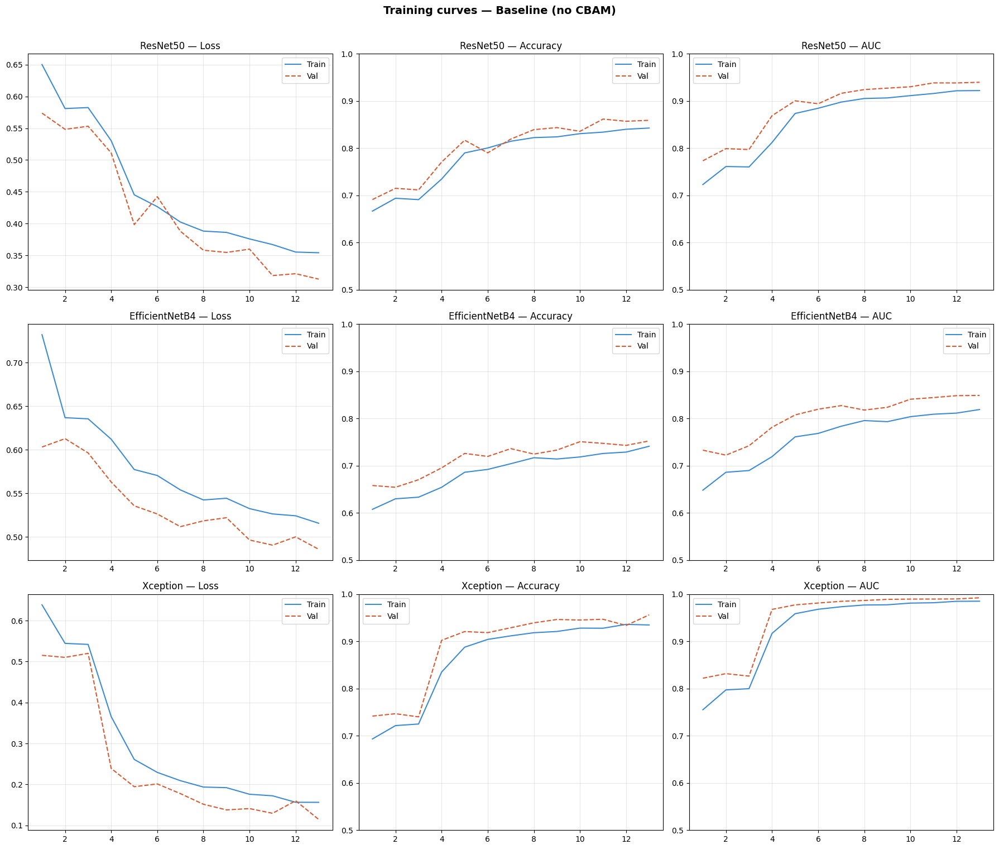

Saved: p4_baseline_training_curves.png


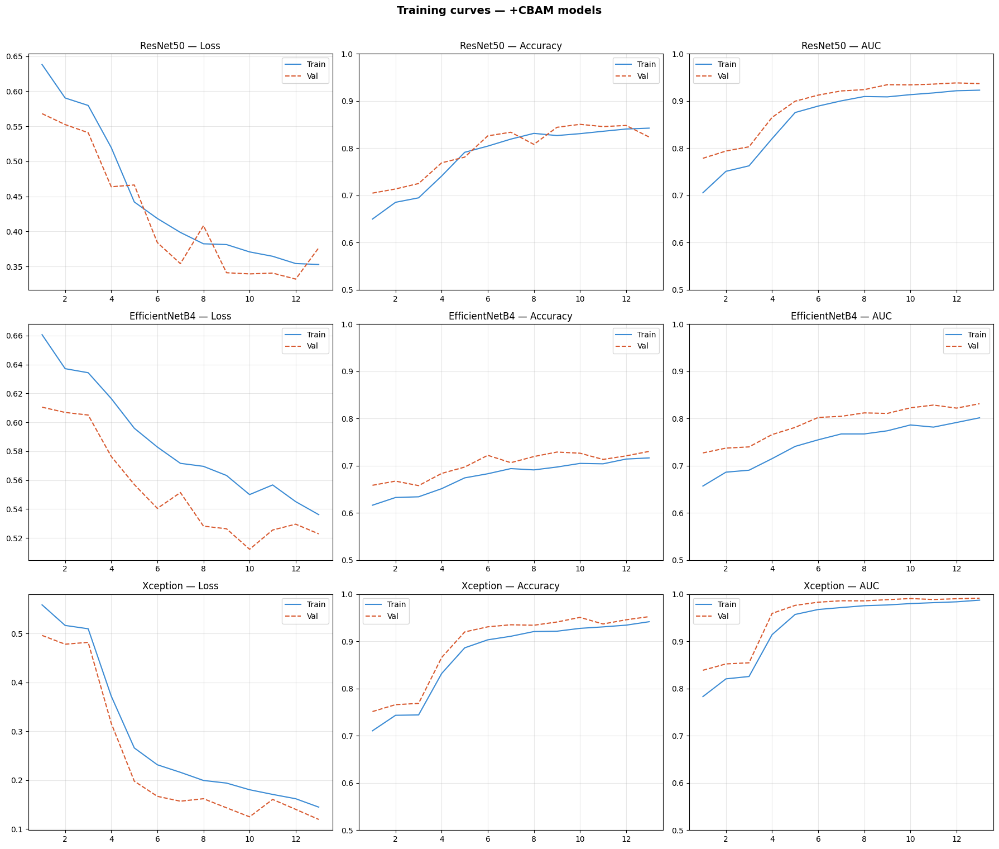

Saved: p4_cbam_training_curves.png


In [22]:
def plot_training_curves(all_results, suffix, title_tag, save_tag):
    items = [(mn, all_results[mn][suffix]["history"])
             for mn in all_results if suffix in all_results[mn]]
    if not items: print("No results to plot."); return
    n = len(items)
    fig, axes = plt.subplots(n, 3, figsize=(18, 5*n))
    fig.suptitle(f"Training curves — {title_tag}",
                 fontsize=14, fontweight="bold", y=1.01)
    if n == 1: axes = [axes]
    for ri, (mn, hist) in enumerate(items):
        eps = range(1, len(hist["loss"])+1)
        for ci, (tr_k, va_k, title) in enumerate([
            ("loss",     "val_loss",     f"{mn} — Loss"),
            ("accuracy", "val_accuracy", f"{mn} — Accuracy"),
            ("auc",      "val_auc",      f"{mn} — AUC"),
        ]):
            axes[ri][ci].plot(eps, hist[tr_k], "#3B8BD4", label="Train")
            axes[ri][ci].plot(eps, hist[va_k], "#D85A30", label="Val", ls="--")
            axes[ri][ci].set_title(title)
            if ci > 0: axes[ri][ci].set_ylim(0.5, 1.0)
            axes[ri][ci].legend(); axes[ri][ci].grid(alpha=0.3)
    plt.tight_layout()
    fname = f"p4_{save_tag}_training_curves.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")
 
plot_training_curves(all_results, "baseline", "Baseline (no CBAM)", "baseline")
plot_training_curves(all_results, "cbam",     "+CBAM models",       "cbam")

## Cell 4.3 — ROC curves

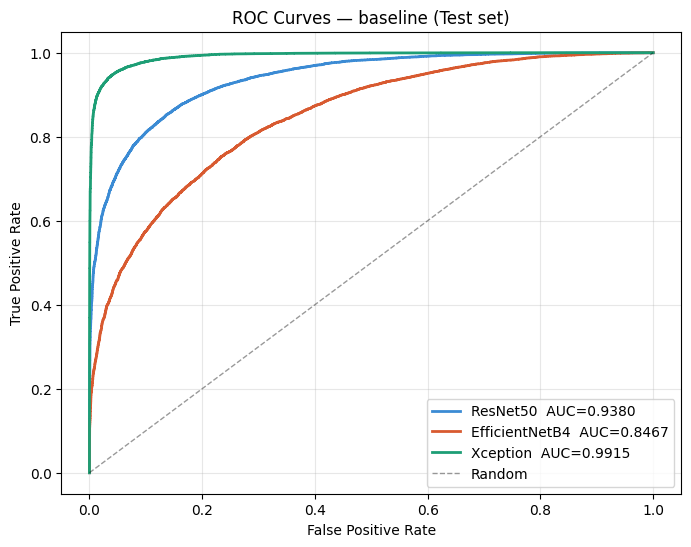

Saved: p4_baseline_roc.png


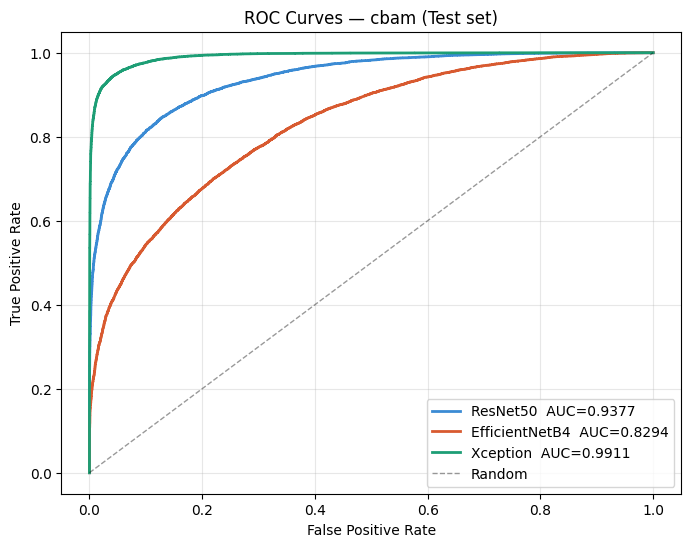

Saved: p4_cbam_roc.png


In [ ]:
def plot_roc(all_results, suffix, summary_df, tag):
    if summary_df.empty: print(f"No {suffix} results."); return
    plt.figure(figsize=(8,6))
    color_map = {"ResNet50":"#3B8BD4","EfficientNetB4":"#D85A30",
                 "Xception":"#1D9E75"}
    for mn, sd in all_results.items():
        if suffix not in sd: continue
        y_true = np.array(sd[suffix]["y_true"])
        y_prob = np.array(sd[suffix]["y_prob"])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = summary_df.loc[mn,"AUC"] if mn in summary_df.index else 0
        plt.plot(fpr, tpr, color=color_map.get(mn,"gray"), lw=2,
                 label=f"{mn}  AUC={auc:.4f}")
    plt.plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves — {tag} (Test set)")
    plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    fname = f"p4_{tag}_roc.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")
 
plot_roc(all_results, "baseline", baseline_summary, "baseline")
plot_roc(all_results, "cbam",     cbam_summary,     "cbam")

## Cell 4.4 — Confusion matrices

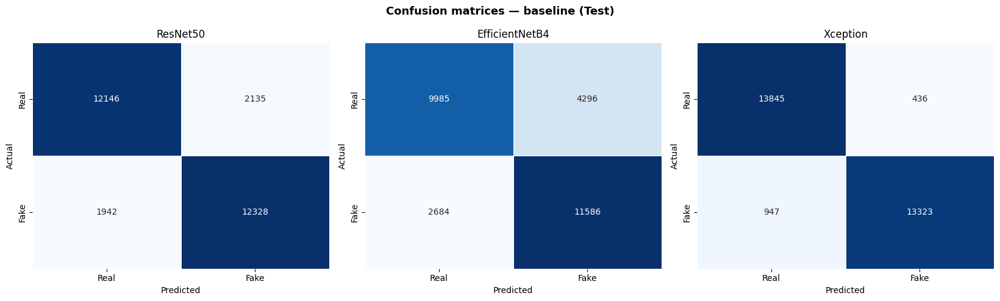

Saved: p4_baseline_confusion_matrices.png


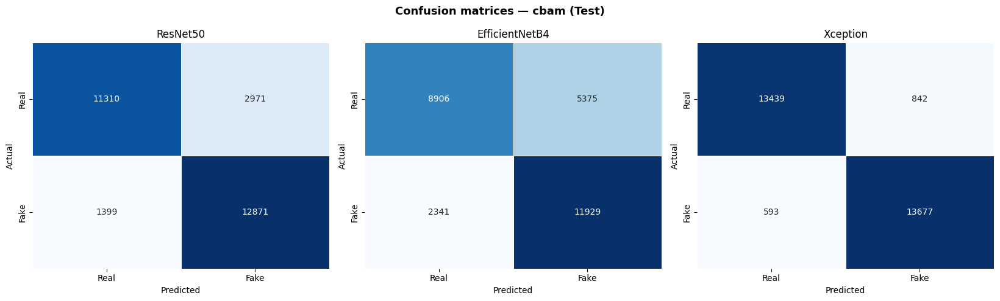

Saved: p4_cbam_confusion_matrices.png


In [ ]:
def plot_cms(all_results, suffix, tag):
    items = [(mn, all_results[mn][suffix])
             for mn in all_results if suffix in all_results[mn]]
    if not items: print("No results."); return
    n = len(items)
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 5))
    if n == 1: axes = [axes]
    fig.suptitle(f"Confusion matrices — {tag} (Test)",
                 fontsize=13, fontweight="bold")
    for ax, (mn, rd) in zip(axes, items):
        y_true = np.array(rd["y_true"])
        y_pred = (np.array(rd["y_prob"]) >= 0.5).astype(int)
        sns.heatmap(confusion_matrix(y_true, y_pred),
                    annot=True, fmt="d", ax=ax, cmap="Blues",
                    xticklabels=["Real","Fake"],
                    yticklabels=["Real","Fake"],
                    linewidths=0.5, cbar=False)
        ax.set_title(mn); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout()
    fname = f"p4_{tag}_confusion_matrices.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")
 
plot_cms(all_results, "baseline", "baseline")
plot_cms(all_results, "cbam",     "cbam")

## Cell 4.5 — Ablation table


  ABLATION — Baseline vs +CBAM (Test set)

  ResNet50
  Metric          Baseline        CBAM     Delta
  ────────────────────────────────────────────
  Accuracy          0.8572      0.8469  -0.0103
  F1                0.8581      0.8549  -0.0032
  AUC               0.9380      0.9377  -0.0003
  Precision         0.8524      0.8125  -0.0399
  Recall            0.8639      0.9020  +0.0381

  EfficientNetB4
  Metric          Baseline        CBAM     Delta
  ────────────────────────────────────────────
  Accuracy          0.7555      0.7297  -0.0258
  F1                0.7685      0.7556  -0.0129
  AUC               0.8467      0.8294  -0.0173
  Precision         0.7295      0.6894  -0.0401
  Recall            0.8119      0.8359  +0.0240

  Xception
  Metric          Baseline        CBAM     Delta
  ────────────────────────────────────────────
  Accuracy          0.9516      0.9497  -0.0019
  F1                0.9507      0.9502  -0.0005
  AUC               0.9915      0.9911  -0.0004
  P

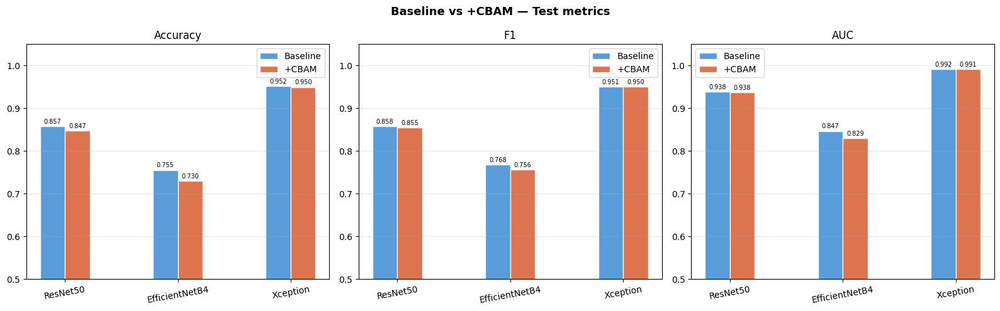

Saved: p4_ablation_bars.png
Phase 4 complete.


In [ ]:
rows = []
for mn in all_results:
    if "baseline" not in all_results[mn] or "cbam" not in all_results[mn]:
        continue
    b = all_results[mn]["baseline"]["metrics"]
    c = all_results[mn]["cbam"]["metrics"]
    row = {"Model": mn}
    for m in metrics_cols:
        row[f"Base_{m}"] = b[m]; row[f"CBAM_{m}"] = c[m]
        row[f"D_{m}"]    = round(c[m]-b[m], 4)
    rows.append(row)
 
ablation_df = pd.DataFrame(rows).set_index("Model") if rows else pd.DataFrame()
if not ablation_df.empty:
    ablation_df.to_csv("p4_ablation_comparison.csv")
    print(f"\n{'='*65}")
    print("  ABLATION — Baseline vs +CBAM (Test set)")
    print(f"{'='*65}")
    for mn, row in ablation_df.iterrows():
        print(f"\n  {mn}")
        print(f"  {'Metric':12s}  {'Baseline':>10}  {'CBAM':>10}  {'Delta':>8}")
        print(f"  {'─'*44}")
        for m in metrics_cols:
            d = row[f"D_{m}"]
            print(f"  {m:12s}  {row[f'Base_{m}']:>10.4f}  "
                  f"{row[f'CBAM_{m}']:>10.4f}  "
                  f"{'+'if d>0 else ''}{d:.4f}")
 
    # Ablation bar chart
    x = np.arange(len(ablation_df)); width = 0.22
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    fig.suptitle("Baseline vs +CBAM — Test metrics", fontsize=13, fontweight="bold")
    for ci, m in enumerate(["Accuracy","F1","AUC"]):
        bv = [ablation_df.loc[mn,f"Base_{m}"] for mn in ablation_df.index]
        cv = [ablation_df.loc[mn,f"CBAM_{m}"] for mn in ablation_df.index]
        axes[ci].bar(x-width/2, bv, width, label="Baseline",
                     color="#3B8BD4", alpha=0.85, edgecolor="white")
        axes[ci].bar(x+width/2, cv, width, label="+CBAM",
                     color="#D85A30", alpha=0.85, edgecolor="white")
        axes[ci].set_xticks(x)
        axes[ci].set_xticklabels(list(ablation_df.index), rotation=10)
        axes[ci].set_ylim(0.5,1.05); axes[ci].set_title(m)
        axes[ci].legend(); axes[ci].grid(axis="y", alpha=0.3)
        for i,(b,c) in enumerate(zip(bv,cv)):
            axes[ci].text(i-width/2, b+0.003, f"{b:.3f}",
                          ha="center", va="bottom", fontsize=7)
            axes[ci].text(i+width/2, c+0.003, f"{c:.3f}",
                          ha="center", va="bottom", fontsize=7)
    plt.tight_layout()
    plt.savefig("p4_ablation_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: p4_ablation_bars.png")
 
print("Phase 4 complete.")

#  PHASE 5 — GRAD-CAM EXPLAINABILITY

## Cell 5.1 — Load models

In [ ]:
keras.backend.clear_session(); gc.collect()
 
try: resnet50_base
except NameError: resnet50_base = load_model_safe("ResNet50","baseline")
try: resnet50_cbam
except NameError: resnet50_cbam = load_model_safe("ResNet50","cbam")
try: effnet_base
except NameError: effnet_base   = load_model_safe("EfficientNetB4","baseline")
try: effnet_cbam
except NameError: effnet_cbam   = load_model_safe("EfficientNetB4","cbam")
try: xception_base
except NameError: xception_base = load_model_safe("Xception","baseline")
try: xception_cbam
except NameError: xception_cbam = load_model_safe("Xception","cbam")
 
models_dict = {
    "ResNet50"      : (resnet50_base, resnet50_cbam),
    "EfficientNetB4": (effnet_base,   effnet_cbam),
    "Xception"      : (xception_base, xception_cbam),
}
print("Models loaded for Grad-CAM++.")

Models loaded for Grad-CAM++.


## Cell 5.2 — Grad-CAM++ implementation

In [ ]:
def get_last_conv_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")
 
 
class GradCAMPlusPlus:
    """
    Grad-CAM++ — Chattopadhay et al., WACV 2018.
    Uses second-order gradient information to compute spatially-varying
    channel weights, producing sharper and more localised heatmaps than
    standard Grad-CAM.
    """
    def __init__(self, model, target_layer_name):
        self.grad_model = keras.Model(
            inputs=model.inputs,
            outputs=[
                model.get_layer(target_layer_name).output,
                model.output
            ]
        )
 
    def generate(self, img_array):
        """
        img_array : (1, H, W, C) normalised tensor
        Returns   : cam (H_feat, W_feat) numpy array in [0,1],
                    pred_label int (0=Real, 1=Fake)
        """
        with tf.GradientTape() as tape2:
            with tf.GradientTape() as tape1:
                conv_out, pred = self.grad_model(img_array, training=False)
                # Watch the feature map tensor (not model variables)
                # so both tapes can compute gradients w.r.t. conv_out
                tape1.watch(conv_out)
                tape2.watch(conv_out)
                loss = pred[:, 0]
 
            # First-order gradients: dLoss / dA  shape (1,H,W,C)
            first_grads = tape1.gradient(loss, conv_out)
 
        # Second-order gradients: d²Loss / dA²  shape (1,H,W,C)
        second_grads = tape2.gradient(first_grads, conv_out)
 
        # Guard: second_grads can be None if the graph path is broken
        if second_grads is None:
            # Graceful fallback to standard Grad-CAM weights
            weights = tf.reduce_mean(first_grads, axis=(1, 2))
            cam = tf.reduce_sum(conv_out[0] * weights[0], axis=-1)
            cam = tf.maximum(cam, 0).numpy()
        else:
            # ── Grad-CAM++ weight formula ─────────────────────────
            # alpha[k,i,j] = second_grad[k,i,j]^2 / (
            #     2 * second_grad[k,i,j]^2
            #     + sum_{a,b}(A[k,a,b]) * third_grad[k,i,j]
            #     + epsilon )
            #
            # For efficiency we approximate third_grads as
            # 2 * second_grads (common approximation in implementations
            # that avoids a third tape, saving memory on Kaggle GPU).
 
            eps          = 1e-7
            A            = conv_out[0]                    # (H,W,C)
            grad2        = second_grads[0]                # (H,W,C)
            global_sum_A = tf.reduce_sum(A, axis=(0, 1), keepdims=True)  # (1,1,C)
 
            # Numerator: grad2^2
            numerator = grad2 ** 2
 
            # Denominator: 2*grad2^2 + A_sum * (2*grad2) + eps
            # (third derivative approximated as 2 * second_derivative)
            denominator = (2.0 * grad2 ** 2
                           + global_sum_A * (2.0 * grad2)
                           + eps)
 
            alpha = numerator / denominator               # (H,W,C)
 
            # Weight per channel = sum of alpha * ReLU(first_grad)
            # Only positive gradients matter (regions that increase loss)
            relu_grad1 = tf.maximum(first_grads[0], 0.0) # (H,W,C)
            weights    = tf.reduce_sum(alpha * relu_grad1,
                                       axis=(0, 1))       # (C,)
 
            # Weighted combination of feature maps
            cam = tf.reduce_sum(A * weights, axis=-1)     # (H,W)
            cam = tf.maximum(cam, 0).numpy()
 
        # Normalise to [0,1]
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
 
        pred_label = int(pred[0, 0].numpy() >= 0.5)
        return cam, pred_label
 
 
# ── Overlay helper (identical to before) ─────────────────────────
_resample = (Image.Resampling.BILINEAR
             if hasattr(Image, "Resampling") else Image.BILINEAR)
 
def overlay_cam(img_tensor, cam, alpha=0.45):
    img = np.clip(
        img_tensor[0].numpy() * IMAGENET_STD.numpy()
        + IMAGENET_MEAN.numpy(), 0, 1)
    cam_r = np.array(
        Image.fromarray((cam * 255).astype(np.uint8))
             .resize((img.shape[1], img.shape[0]), _resample)
    ) / 255.0
    return np.clip(
        (1 - alpha) * img + alpha * plt.cm.jet(cam_r)[:, :, :3], 0, 1)

## Cell 5.3 — Collect sample images

In [ ]:
sample_imgs, sample_lbls = [], []
real_n = fake_n = 0
for imgs, lbls in test_ds:
    for img, lbl in zip(imgs, lbls):
        lv = int(lbl.numpy())
        if lv == 0 and real_n < 2:
            sample_imgs.append(tf.expand_dims(img, 0))
            sample_lbls.append(lv); real_n += 1
        elif lv == 1 and fake_n < 2:
            sample_imgs.append(tf.expand_dims(img, 0))
            sample_lbls.append(lv); fake_n += 1
        if real_n >= 2 and fake_n >= 2: break
    if real_n >= 2 and fake_n >= 2: break
print(f"Collected {len(sample_imgs)} sample images for Grad-CAM++.")

Collected 4 sample images for Grad-CAM++.


## Cell 5.4 — Grad-CAM++ comparison grids

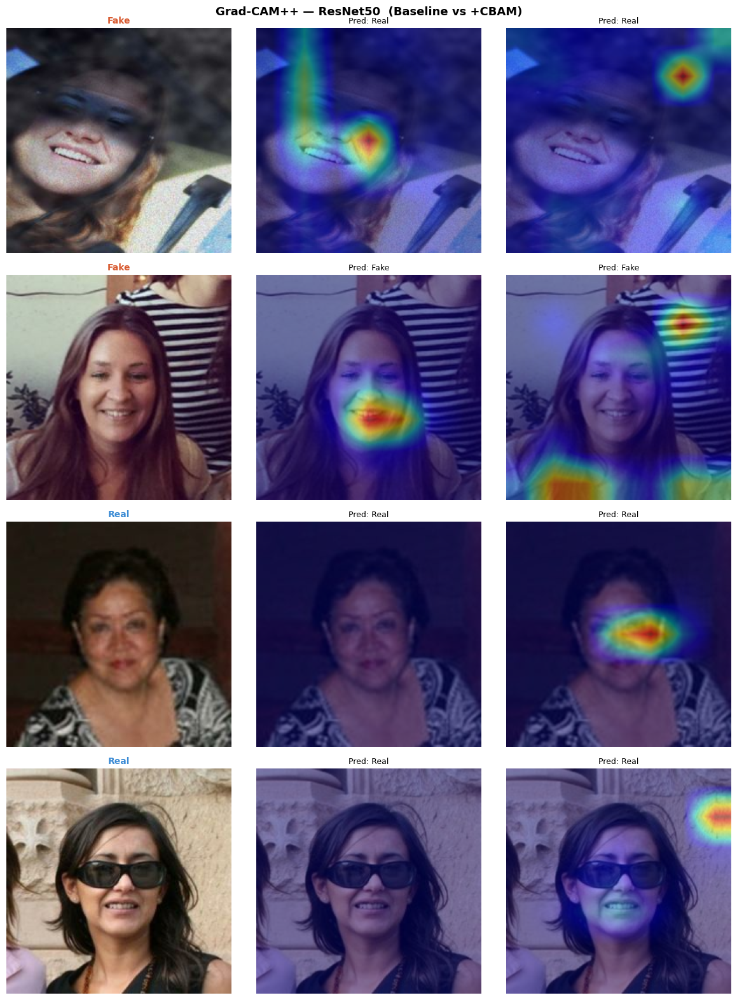

Saved: p5_gradcampp_resnet50_comparison.png


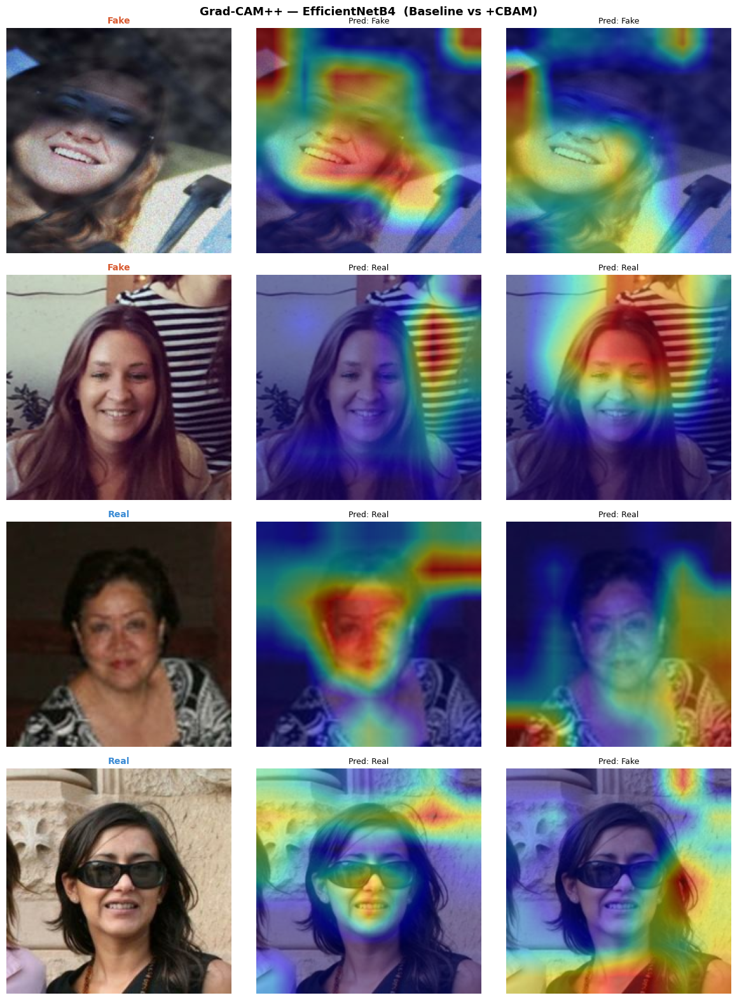

Saved: p5_gradcampp_efficientnetb4_comparison.png


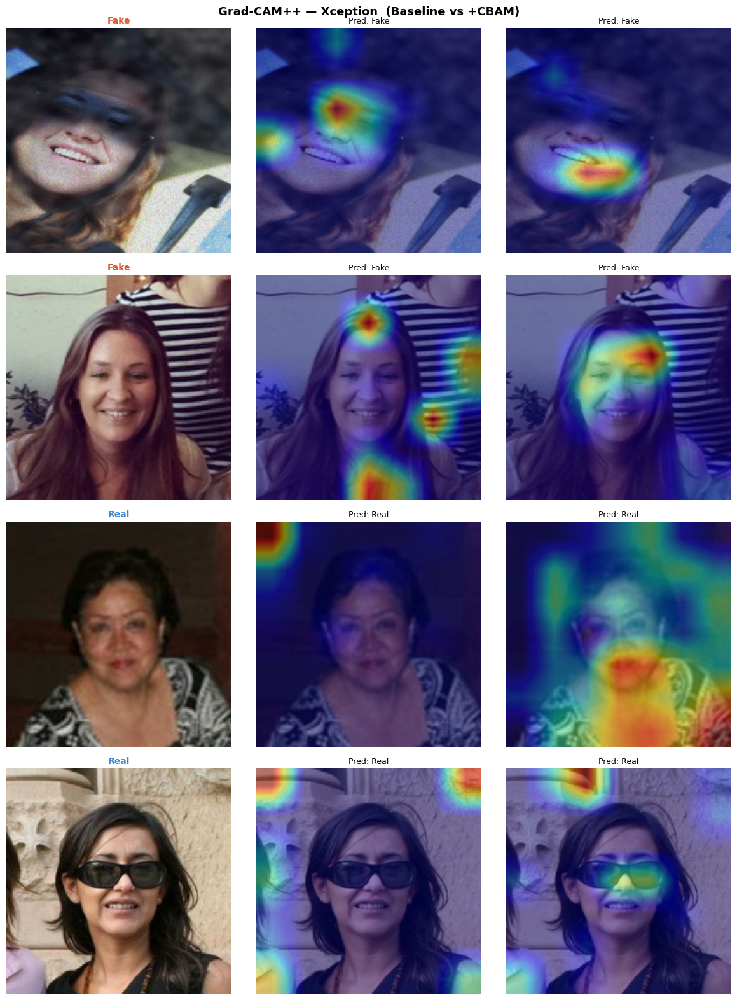

Saved: p5_gradcampp_xception_comparison.png


In [ ]:
lname = {0: "Real", 1: "Fake"}
lcol  = {0: "#3B8BD4", 1: "#D85A30"}
 
for mname, (base_m, cbam_m) in models_dict.items():
    if base_m is None or cbam_m is None:
        print(f"  {mname}: model missing, skipping."); continue
 
    base_gcam = GradCAMPlusPlus(base_m, get_last_conv_name(base_m))
    cbam_gcam = GradCAMPlusPlus(cbam_m, get_last_conv_name(cbam_m))
 
    n = len(sample_imgs)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    fig.suptitle(f"Grad-CAM++ — {mname}  (Baseline vs +CBAM)",
                 fontsize=13, fontweight="bold")
    for t, ci in zip(
        ["Original", "Baseline Grad-CAM++", "+CBAM Grad-CAM++"],
        range(3)
    ):
        axes[0][ci].set_title(t, fontsize=11)
 
    for ri, (img_t, lbl) in enumerate(zip(sample_imgs, sample_lbls)):
        orig = np.clip(
            img_t[0].numpy() * IMAGENET_STD.numpy()
            + IMAGENET_MEAN.numpy(), 0, 1)
 
        # Original
        axes[ri][0].imshow(orig)
        axes[ri][0].axis("off")
        axes[ri][0].set_title(lname[lbl], fontsize=10,
                              fontweight="bold", color=lcol[lbl])
 
        # Baseline Grad-CAM++
        cam_b, pred_b = base_gcam.generate(img_t)
        axes[ri][1].imshow(overlay_cam(img_t, cam_b))
        axes[ri][1].set_title(f"Pred: {lname[pred_b]}", fontsize=9)
        axes[ri][1].axis("off")
 
        # CBAM Grad-CAM++
        cam_c, pred_c = cbam_gcam.generate(img_t)
        axes[ri][2].imshow(overlay_cam(img_t, cam_c))
        axes[ri][2].set_title(f"Pred: {lname[pred_c]}", fontsize=9)
        axes[ri][2].axis("off")
 
    plt.tight_layout()
    fname = f"p5_gradcampp_{mname.lower()}_comparison.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Cell 5.5 — CBAM attention maps

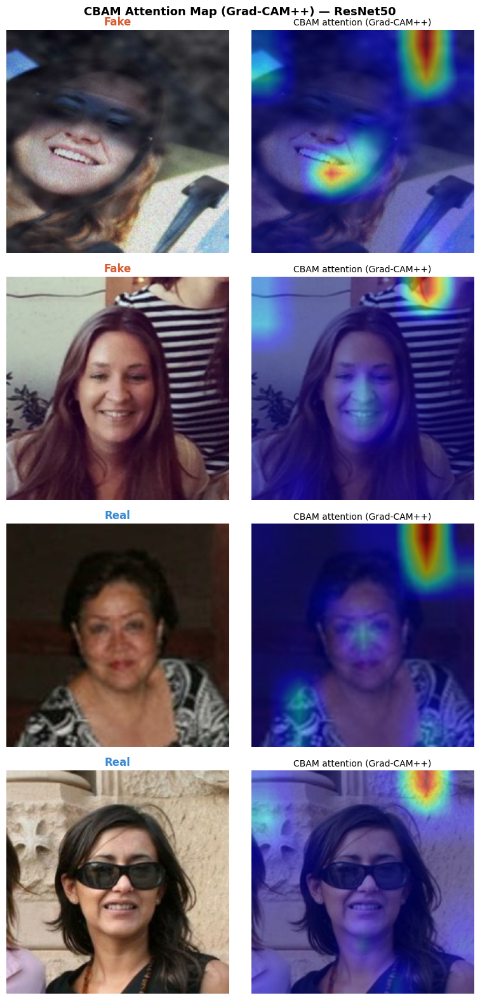

Saved: p5_cbam_attention_resnet50.png


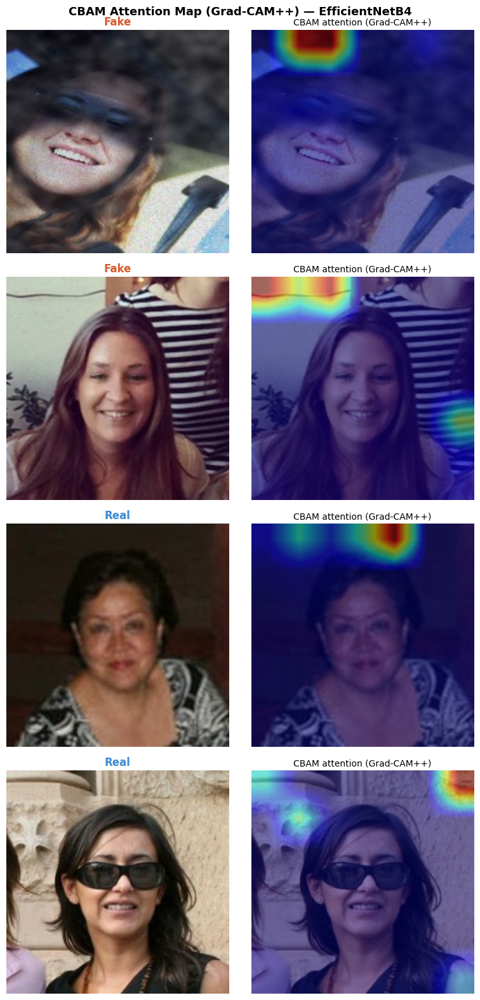

Saved: p5_cbam_attention_efficientnetb4.png


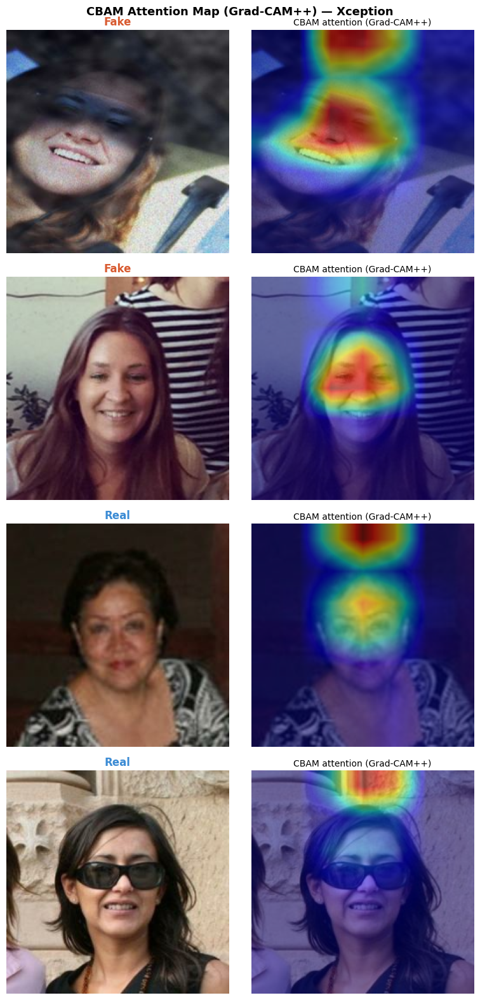

Saved: p5_cbam_attention_xception.png
Phase 5 complete — Grad-CAM++ heatmaps saved.


In [ ]:
for mname, (_, cbam_m) in models_dict.items():
    if cbam_m is None:
        print(f"  {mname} CBAM missing, skipping."); continue
 
    cbam_gcam = GradCAMPlusPlus(cbam_m, "cbam")
    n = len(sample_imgs)
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    fig.suptitle(f"CBAM Attention Map (Grad-CAM++) — {mname}",
                 fontsize=13, fontweight="bold")
 
    for ri, (img_t, lbl) in enumerate(zip(sample_imgs, sample_lbls)):
        orig = np.clip(
            img_t[0].numpy() * IMAGENET_STD.numpy()
            + IMAGENET_MEAN.numpy(), 0, 1)
        cam, _ = cbam_gcam.generate(img_t)
        cam_r  = np.array(
            Image.fromarray((cam * 255).astype(np.uint8))
                 .resize((IMG_SIZE, IMG_SIZE), _resample)
        ) / 255.0
 
        axes[ri][0].imshow(orig)
        axes[ri][0].axis("off")
        axes[ri][0].set_title(lname[lbl], color=lcol[lbl],
                              fontweight="bold")
 
        axes[ri][1].imshow(orig)
        axes[ri][1].imshow(cam_r, cmap="jet", alpha=0.5)
        axes[ri][1].set_title("CBAM attention (Grad-CAM++)", fontsize=10)
        axes[ri][1].axis("off")
 
    plt.tight_layout()
    fname = f"p5_cbam_attention_{mname.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")
 
print("Phase 5 complete — Grad-CAM++ heatmaps saved.")

#  PHASE 6 — RESULTS TABLE & PAPER EXPORT

## Cell 6.1 — Reload and combine 

In [ ]:
all_results      = load_all_results()
baseline_summary = build_summary(all_results, "baseline")
cbam_summary     = build_summary(all_results, "cbam")
 
def add_type(df_, t):
    d = df_[metrics_cols].copy(); d.insert(0,"Type",t); return d
 
final_df = pd.concat([add_type(baseline_summary,"Baseline"),
                      add_type(cbam_summary,    "+CBAM")])
final_df.index.name = "Model"
final_df.to_csv("p6_final_results.csv")
print(final_df.to_string())

                    Type  Accuracy      F1     AUC  Precision  Recall
Model                                                                
ResNet50        Baseline    0.8572  0.8581  0.9380     0.8524  0.8639
EfficientNetB4  Baseline    0.7555  0.7685  0.8467     0.7295  0.8119
Xception        Baseline    0.9516  0.9507  0.9915     0.9683  0.9336
ResNet50           +CBAM    0.8469  0.8549  0.9377     0.8125  0.9020
EfficientNetB4     +CBAM    0.7297  0.7556  0.8294     0.6894  0.8359
Xception           +CBAM    0.9497  0.9502  0.9911     0.9420  0.9584


## Cell 6.2 — Combined ROC

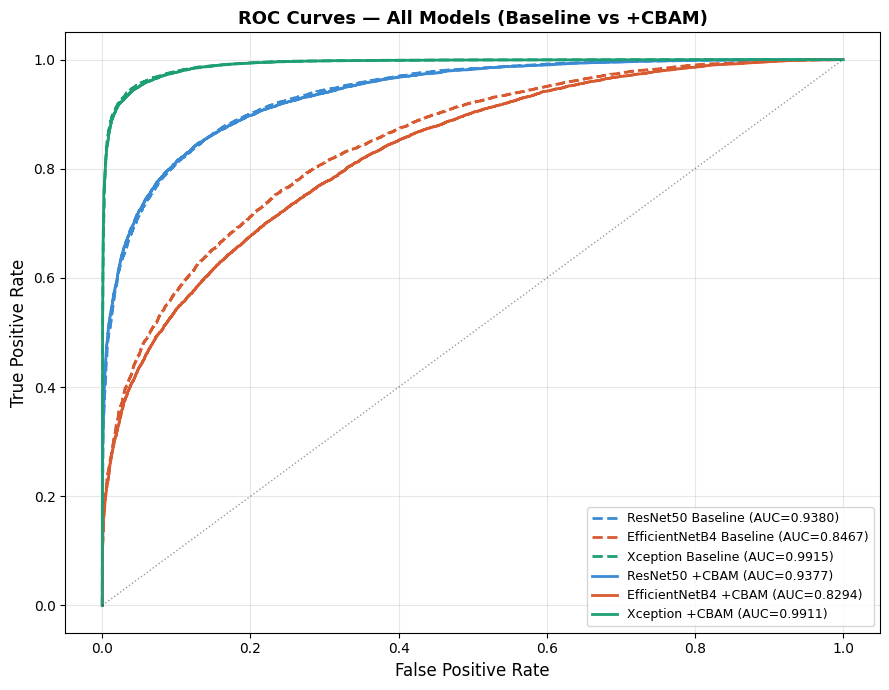

Saved: p6_combined_roc.png


In [ ]:
plt.figure(figsize=(9,7))
ls_map    = {"baseline":"--","cbam":"-"}
color_map = {"ResNet50":"#3B8BD4","EfficientNetB4":"#D85A30","Xception":"#1D9E75"}
lbl_map   = {"baseline":"Baseline","cbam":"+CBAM"}
 
for sf in ["baseline","cbam"]:
    sdf = baseline_summary if sf=="baseline" else cbam_summary
    for mn, sd in all_results.items():
        if sf not in sd: continue
        y_true = np.array(sd[sf]["y_true"])
        y_prob = np.array(sd[sf]["y_prob"])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = sdf.loc[mn,"AUC"] if mn in sdf.index else 0
        plt.plot(fpr, tpr, color=color_map.get(mn,"gray"),
                 ls=ls_map[sf], lw=2,
                 label=f"{mn} {lbl_map[sf]} (AUC={auc:.4f})")
 
plt.plot([0,1],[0,1],"k:",lw=1,alpha=0.4)
plt.xlabel("False Positive Rate",fontsize=12)
plt.ylabel("True Positive Rate",fontsize=12)
plt.title("ROC Curves — All Models (Baseline vs +CBAM)",
          fontsize=13, fontweight="bold")
plt.legend(loc="lower right",fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("p6_combined_roc.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: p6_combined_roc.png")

## Cell 6.3 — Combined confusion matrix panel

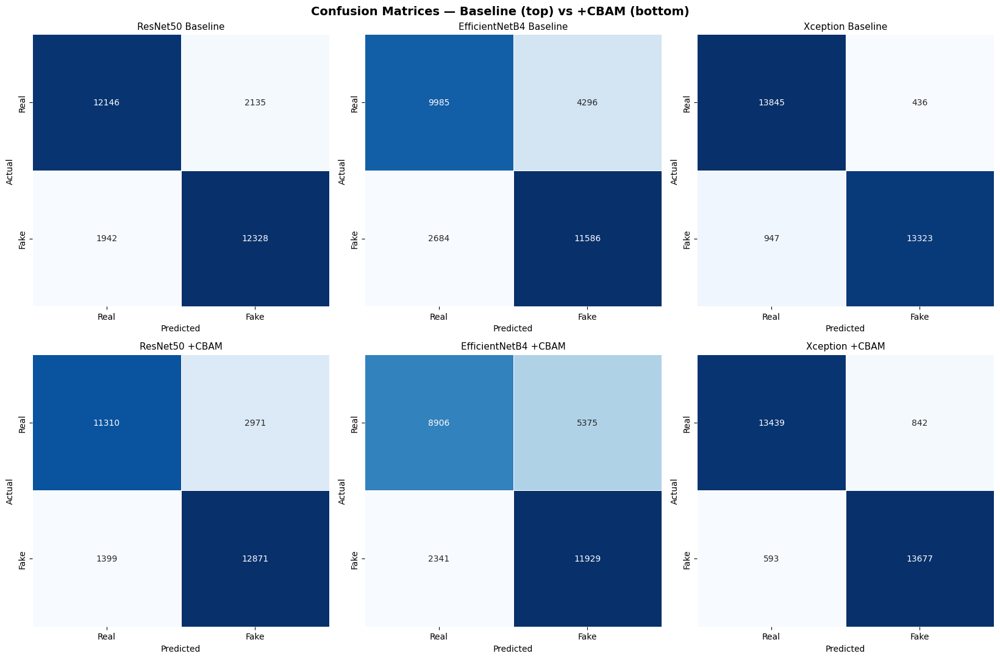

Saved: p6_all_confusion_matrices.png


In [ ]:
model_names = list(all_results.keys())
n = len(model_names)
if n > 0:
    fig, axes = plt.subplots(2, n, figsize=(5.5*n, 11))
    fig.suptitle("Confusion Matrices — Baseline (top) vs +CBAM (bottom)",
                 fontsize=14, fontweight="bold")
    for ci, mn in enumerate(model_names):
        for ri, sf in enumerate(["baseline","cbam"]):
            if sf not in all_results[mn]: continue
            y_true = np.array(all_results[mn][sf]["y_true"])
            y_pred = (np.array(all_results[mn][sf]["y_prob"]) >= 0.5).astype(int)
            sns.heatmap(confusion_matrix(y_true, y_pred),
                        annot=True, fmt="d", ax=axes[ri][ci], cmap="Blues",
                        xticklabels=["Real","Fake"],
                        yticklabels=["Real","Fake"],
                        linewidths=0.5, cbar=False)
            axes[ri][ci].set_title(
                f"{mn} {'Baseline' if sf=='baseline' else '+CBAM'}", fontsize=11)
            axes[ri][ci].set_xlabel("Predicted")
            axes[ri][ci].set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig("p6_all_confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: p6_all_confusion_matrices.png")

## Cell 6.4 — Delta heatmap

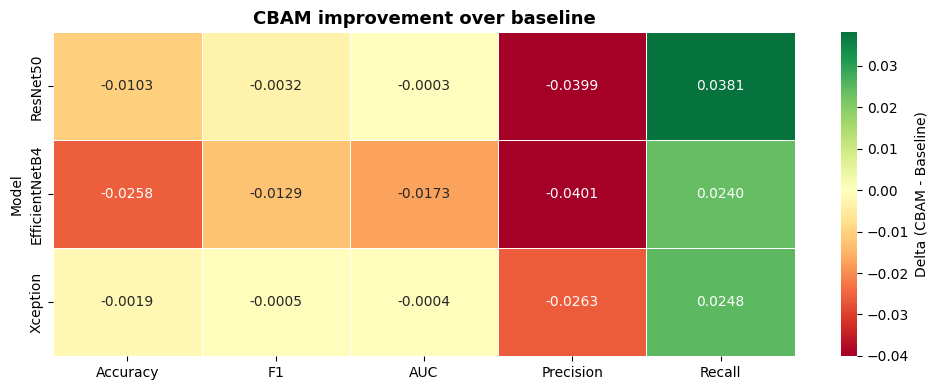

Saved: p6_delta_heatmap.png


In [ ]:
if not ablation_df.empty:
    delta_plot = ablation_df[[f"D_{m}" for m in metrics_cols]].copy()
    delta_plot.columns = metrics_cols
    fig, ax = plt.subplots(figsize=(10,4))
    sns.heatmap(delta_plot, annot=True, fmt=".4f", cmap="RdYlGn",
                center=0, linewidths=0.5, ax=ax,
                cbar_kws={"label":"Delta (CBAM - Baseline)"})
    ax.set_title("CBAM improvement over baseline",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("p6_delta_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: p6_delta_heatmap.png")

## Cell 6.5 — LaTeX table

In [ ]:
def df_to_latex(df_, caption, label):
    lines = [r"\begin{table}[!t]", r"\centering",
             rf"\caption{{{caption}}}", rf"\label{{{label}}}",
             r"\begin{tabular}{ll" + "c"*len(metrics_cols) + "}",
             r"\hline",
             r"\textbf{Model} & \textbf{Type} & " +
             " & ".join(f"\\textbf{{{m}}}" for m in metrics_cols) + r" \\",
             r"\hline"]
    cur = None
    for mn, row in df_.iterrows():
        if mn != cur:
            if cur is not None: lines.append(r"\hline")
            cur = mn
        vals = " & ".join(f"{row[m]:.4f}" for m in metrics_cols)
        lines.append(f"{mn} & {row['Type']} & {vals} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)
 
latex_str = df_to_latex(
    final_df,
    caption=(r"Comparative results: Baseline vs.\ CBAM-enhanced models "
             r"on the deepfake detection test set (70/15/15 split, seed=42)."),
    label="tab:results")
with open("p6_latex_table.tex","w") as f: f.write(latex_str)
print(latex_str)
print("\nSaved: p6_latex_table.tex")

\begin{table}[!t]
\centering
\caption{Comparative results: Baseline vs.\ CBAM-enhanced models on the deepfake detection test set (70/15/15 split, seed=42).}
\label{tab:results}
\begin{tabular}{llccccc}
\hline
\textbf{Model} & \textbf{Type} & \textbf{Accuracy} & \textbf{F1} & \textbf{AUC} & \textbf{Precision} & \textbf{Recall} \\
\hline
ResNet50 & Baseline & 0.8572 & 0.8581 & 0.9380 & 0.8524 & 0.8639 \\
\hline
EfficientNetB4 & Baseline & 0.7555 & 0.7685 & 0.8467 & 0.7295 & 0.8119 \\
\hline
Xception & Baseline & 0.9516 & 0.9507 & 0.9915 & 0.9683 & 0.9336 \\
\hline
ResNet50 & +CBAM & 0.8469 & 0.8549 & 0.9377 & 0.8125 & 0.9020 \\
\hline
EfficientNetB4 & +CBAM & 0.7297 & 0.7556 & 0.8294 & 0.6894 & 0.8359 \\
\hline
Xception & +CBAM & 0.9497 & 0.9502 & 0.9911 & 0.9420 & 0.9584 \\
\hline
\end{tabular}
\end{table}

Saved: p6_latex_table.tex


## Cell 6.6 — Final summary

In [ ]:
print("\n" + "="*62)
print("  FINAL PAPER SUMMARY")
print("="*62)
if not baseline_summary.empty and not cbam_summary.empty:
    best_b = baseline_summary["AUC"].idxmax()
    best_c = cbam_summary["AUC"].idxmax()
    print(f"  Best baseline : {best_b}  "
          f"AUC={baseline_summary.loc[best_b,'AUC']:.4f}")
    print(f"  Best CBAM     : {best_c}  "
          f"AUC={cbam_summary.loc[best_c,'AUC']:.4f}")
    print(f"  AUC gain      : "
          f"+{cbam_summary.loc[best_c,'AUC'] - baseline_summary.loc[best_b,'AUC']:.4f}")
 
print("\n  Checkpoint status:")
for mn in ["ResNet50","EfficientNetB4","Xception"]:
    for sf in ["baseline","cbam"]:
        p = ckpt_path(mn, sf)
        print(f"    [{'OK' if Path(p).exists() else 'MISSING'}] {p}")
 
print("\n  Results JSON status:")
for mn in ["ResNet50","EfficientNetB4","Xception"]:
    for sf in ["baseline","cbam"]:
        p = RESULTS_DIR / f"{mn}_{sf}.json"
        print(f"    [{'OK' if p.exists() else 'MISSING'}] {p}")
 
print("\n  All plots  : p1_* p2_* p4_* p5_* p6_*")
print("  LaTeX      : p6_latex_table.tex")
print("  Split CSV  : custom_split.csv")
print("="*62)


  FINAL PAPER SUMMARY
  Best baseline : Xception  AUC=0.9915
  Best CBAM     : Xception  AUC=0.9911
  AUC gain      : +-0.0004

  Checkpoint status:
    [OK] resnet50_baseline.keras
    [OK] resnet50_cbam.keras
    [OK] efficientnetb4_baseline.keras
    [OK] efficientnetb4_cbam.keras
    [OK] xception_baseline.keras
    [OK] xception_cbam.keras

  Results JSON status:
    [OK] results/ResNet50_baseline.json
    [OK] results/ResNet50_cbam.json
    [OK] results/EfficientNetB4_baseline.json
    [OK] results/EfficientNetB4_cbam.json
    [OK] results/Xception_baseline.json
    [OK] results/Xception_cbam.json

  All plots  : p1_* p2_* p4_* p5_* p6_*
  LaTeX      : p6_latex_table.tex
  Split CSV  : custom_split.csv
